## Building GP Models from Scratch
Sometimes it is useful to build GP models outside the context of BO for data
visualization and senativity measurements, ie. learned hyperparameters. Here we
demonstrate how to build models from data outside of generators.

For this we use the 3D rosenbrock function test function.

In [1]:
# set values if testing
import os

from xopt import Xopt, Evaluator
from xopt.generators import RandomGenerator
from xopt.resources.test_functions.rosenbrock import (
    make_rosenbrock_vocs,
)

from xopt.generators.bayesian.visualize import visualize_model
from xopt.generators.bayesian.models import StandardModelConstructor

SMOKE_TEST = os.environ.get("SMOKE_TEST")

# make rosenbrock function vocs in 3D
vocs = make_rosenbrock_vocs(3)

def evaluate_func(X):
    return {"y": X["x0"] ** 2 + X["x1"] ** 2}

# collect some data using random sampling
evaluator = Evaluator(function=evaluate_func)
generator = RandomGenerator(vocs=vocs)
X = Xopt(generator=generator, evaluator=evaluator)
X.random_evaluate(15)

C:\Users\Ryan Roussel\Documents\GitHub\Xopt\xopt\pydantic.py:39: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.json import custom_pydantic_encoder


,x0,x1,x2,y,xopt_runtime,xopt_error
0,1.441835,-1.899973,-1.322160,5.688787,3.499968e-06,False
1,0.038882,-0.062271,-0.003226,0.005390,1.900014e-06,False
2,-0.032775,-0.712506,-1.820304,0.508739,1.200009e-06,False
3,-1.714610,-0.610439,1.037405,3.312523,9.000069e-07,False
4,-1.606494,-0.620783,-1.838386,2.966194,1.000008e-06,False
5,-0.553693,-1.640681,1.709442,2.998410,9.000069e-07,False
6,-0.690390,0.726443,-1.960929,1.004359,9.000069e-07,False
7,0.067712,-0.836368,-0.716185,0.704097,7.000053e-07,False
8,-1.984610,0.342996,1.960066,4.056325,8.000061e-07,False
9,1.861432,-0.070051,1.460965,3.469837,7.000053e-07,False


## Standard Model Constructor

In [2]:
print(StandardModelConstructor.__doc__)


A class for constructing independent models for each objective and constraint.

Attributes
----------
name : str
    The name of the model (frozen).

use_low_noise_prior : bool
    Specify if the model should assume a low noise environment.

covar_modules : Dict[str, Kernel]
    Covariance modules for GP models.

mean_modules : Dict[str, Module]
    Prior mean modules for GP models.

trainable_mean_keys : List[str]
    List of prior mean modules that can be trained.

transform_inputs : Union[Dict[str, bool], bool]
    Specify if inputs should be transformed inside the GP model. Can optionally
    specify a dict of specifications.

custom_noise_prior : Optional[Prior]
    Specify a custom noise prior for the GP likelihood. Overwrites value specified
    by use_low_noise_prior.

use_cached_hyperparameters : Optional[bool]
    Flag to specify if cached hyperparameters should be used in model creation.
    Training will still occur unless train_model is False.

train_method : Literal["lbf

## Create GP model based on the data

In [3]:
data = X.data

In [ ]:
model_constructor = StandardModelConstructor(saas_outputs=["y"])

# here we build a model from info (more flexible)
model = model_constructor.build_model(
    input_names=vocs.variable_names, 
    outcome_names=["y"], 
    data=data, 
)


In [5]:
objective_model = model.models[vocs.output_names.index("y")]

# print raw hyperparameter values
for name, val in objective_model.named_parameters():
    print(name, val)

likelihood.noise_covar.raw_noise Parameter containing:
tensor([-9.2103], requires_grad=True)
mean_module.raw_constant Parameter containing:
tensor(0.0375, requires_grad=True)
covar_module.raw_outputscale Parameter containing:
tensor(7.7638, requires_grad=True)
covar_module.base_kernel.raw_lengthscale Parameter containing:
tensor([[1.7046, 1.8655, 9.2103]], requires_grad=True)
covar_module.base_kernel.raw_tau Parameter containing:
tensor(-6.9078, requires_grad=True)


## Visualize model predictions

findfont: Font family ['DejaVu Sans Display'] not found. Falling back to DejaVu Sans.


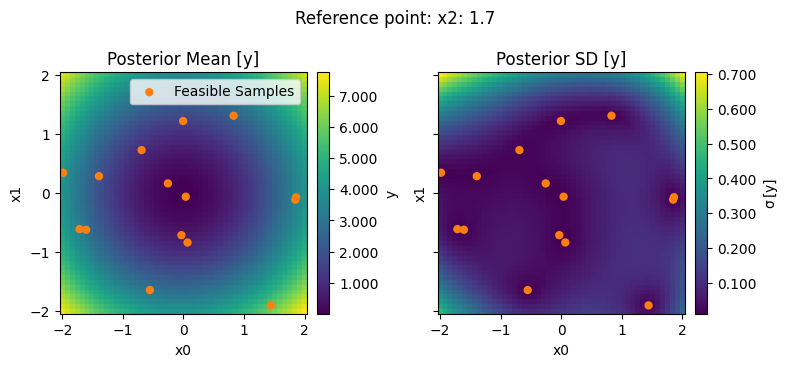

In [6]:
fig, ax = visualize_model(
    model, vocs, data, variable_names=["x0", "x1"], reference_point=data.iloc[-1][vocs.variable_names].to_dict()
)

In [7]:
data.iloc[-1][vocs.variable_names].to_dict()

{'x0': 0.8296234531171609, 'x1': 1.3067972159405206, 'x2': 1.7292349786123893}

## Using Custom Kernels via covar_modules

The `covar_modules` parameter in `StandardModelConstructor` allows you to specify custom GPyTorch kernels for specific outputs. This is useful when you have domain knowledge about the function structure.

In [8]:
from gpytorch.kernels import MaternKernel, ScaleKernel

# Example 1: Use a specific kernel for the objective
# Here we use a Matern kernel with nu=2.5 for the objective "y"
custom_covar_modules = {
    "y": ScaleKernel(MaternKernel(nu=2.5))  # Matern 5/2 kernel for objective
}

model_constructor_custom = StandardModelConstructor(
    covar_modules=custom_covar_modules, use_low_noise_prior=True
)

# Build model with custom kernel
custom_model = model_constructor_custom.build_model_from_vocs(vocs=vocs, data=data)

print("Custom model with Matern kernel:")
print(f"Kernel type: {custom_model.models[0].covar_module}")
print(f"Nu parameter: {custom_model.models[0].covar_module.base_kernel.nu}")

Custom model with Matern kernel:
Kernel type: ScaleKernel(
  (base_kernel): MaternKernel(
    (raw_lengthscale_constraint): Positive()
  )
  (raw_outputscale_constraint): Positive()
)
Nu parameter: 2.5
